In [73]:
import pandas as pd
import feature_engineering_helper as hf
import pickle

In [74]:
import feature_engineering_helper as hf
print(hf.__file__)

/Users/sdl5_mp/Documents/GitHub/melting_point_2026/MW/feature_engineering_helper.py


In [75]:
### change this to 1 for quick test, 0 for full run
quick_test = 0
### change this to 1 for quick test, 0 for full run


if quick_test == 1:
    n_features_to_select=20
    num_feat_binary_interaction = 20
    step=50
    print("Quick test mode")
else:
    n_features_to_select=1
    step=5
    num_feat_binary_interaction = 20
    print("Full run mode")



Full run mode


In [ ]:
data_prefix_MW = '../MW/artifacts_threshold/'

if quick_test == 1:
    df_all_feature = pd.read_parquet(data_prefix_MW + 'all_features_RDKit_60(split)_MW(label)_90(threshold).parquet').head(500)
else:
    df_all_feature = pd.read_parquet(data_prefix_MW + 'all_features_RDKit_60(split)_MW(label)_90(threshold).parquet')

df_all_feature

,MP,MW,MW_label,RDKit_AvgIpc,RDKit_BCUT2D_CHGHI,RDKit_BCUT2D_CHGLO,RDKit_BCUT2D_LOGPHI,RDKit_BCUT2D_LOGPLOW,RDKit_BCUT2D_MRHI,RDKit_BCUT2D_MRLOW,RDKit_BCUT2D_MWHI,RDKit_BCUT2D_MWLOW,RDKit_BalabanJ,RDKit_BertzCT,RDKit_Chi0,RDKit_Chi0n,RDKit_Chi0v,RDKit_Chi1,RDKit_Chi1n,RDKit_Chi1v,RDKit_Chi2n,RDKit_Chi2v,RDKit_Chi3n,RDKit_Chi3v,RDKit_Chi4n,RDKit_Chi4v,RDKit_EState_VSA1,RDKit_EState_VSA10,RDKit_EState_VSA11,RDKit_EState_VSA2,RDKit_EState_VSA3,RDKit_EState_VSA4,RDKit_EState_VSA5,RDKit_EState_VSA6,RDKit_EState_VSA7,RDKit_EState_VSA8,RDKit_EState_VSA9,RDKit_ExactMolWt,RDKit_FpDensityMorgan1,RDKit_FpDensityMorgan2,RDKit_FpDensityMorgan3,RDKit_FractionCSP3,RDKit_HallKierAlpha,RDKit_HeavyAtomCount,RDKit_HeavyAtomMolWt,RDKit_Ipc,RDKit_Kappa1,RDKit_Kappa2,RDKit_Kappa3,RDKit_LabuteASA,RDKit_MaxAbsEStateIndex,RDKit_MaxAbsPartialCharge,RDKit_MaxEStateIndex,RDKit_MaxPartialCharge,RDKit_MinAbsEStateIndex,RDKit_MinAbsPartialCharge,RDKit_MinEStateIndex,RDKit_MinPartialCharge,RDKit_MolLogP,RDKit_MolMR,RDKit_MolWt,RDKit_NHOHCount,RDKit_NOCount,RDKit_NumAliphaticCarbocycles,RDKit_NumAliphaticHeterocycles,RDKit_NumAliphaticRings,RDKit_NumAmideBonds,RDKit_NumAromaticCarbocycles,RDKit_NumAromaticHeterocycles,RDKit_NumAromaticRings,RDKit_NumAtomStereoCenters,RDKit_NumBridgeheadAtoms,RDKit_NumHAcceptors,RDKit_NumHDonors,RDKit_NumHeteroatoms,RDKit_NumHeterocycles,RDKit_NumRadicalElectrons,RDKit_NumRotatableBonds,RDKit_NumSaturatedCarbocycles,RDKit_NumSaturatedHeterocycles,RDKit_NumSaturatedRings,RDKit_NumSpiroAtoms,RDKit_NumUnspecifiedAtomStereoCenters,RDKit_NumValenceElectrons,RDKit_PEOE_VSA1,RDKit_PEOE_VSA10,RDKit_PEOE_VSA11,RDKit_PEOE_VSA12,RDKit_PEOE_VSA13,RDKit_PEOE_VSA14,RDKit_PEOE_VSA2,RDKit_PEOE_VSA3,RDKit_PEOE_VSA4,RDKit_PEOE_VSA5,RDKit_PEOE_VSA6,RDKit_PEOE_VSA7,RDKit_PEOE_VSA8,RDKit_PEOE_VSA9,RDKit_Phi,RDKit_RingCount,RDKit_SMR_VSA1,RDKit_SMR_VSA10,RDKit_SMR_VSA2,RDKit_SMR_VSA3,RDKit_SMR_VSA4,RDKit_SMR_VSA5,RDKit_SMR_VSA6,RDKit_SMR_VSA7,RDKit_SMR_VSA8,RDKit_SMR_VSA9,RDKit_SPS,RDKit_SlogP_VSA1,RDKit_SlogP_VSA10,RDKit_SlogP_VSA11,RDKit_SlogP_VSA12,RDKit_SlogP_VSA2,RDKit_SlogP_VSA3,RDKit_SlogP_VSA4,RDKit_SlogP_VSA5,RDKit_SlogP_VSA6,RDKit_SlogP_VSA7,RDKit_SlogP_VSA8,RDKit_SlogP_VSA9,RDKit_TPSA,RDKit_VSA_EState1,RDKit_VSA_EState10,RDKit_VSA_EState2,RDKit_VSA_EState3,RDKit_VSA_EState4,RDKit_VSA_EState5,RDKit_VSA_EState6,RDKit_VSA_EState7,RDKit_VSA_EState8,RDKit_VSA_EState9,RDKit_fr_Al_COO,RDKit_fr_Al_OH,RDKit_fr_Al_OH_noTert,RDKit_fr_ArN,RDKit_fr_Ar_COO,RDKit_fr_Ar_N,RDKit_fr_Ar_NH,RDKit_fr_Ar_OH,RDKit_fr_COO,RDKit_fr_COO2,RDKit_fr_C_O,RDKit_fr_C_O_noCOO,RDKit_fr_C_S,RDKit_fr_HOCCN,RDKit_fr_Imine,RDKit_fr_NH0,RDKit_fr_NH1,RDKit_fr_NH2,RDKit_fr_N_O,RDKit_fr_Ndealkylation1,RDKit_fr_Ndealkylation2,RDKit_fr_Nhpyrrole,RDKit_fr_SH,RDKit_fr_aldehyde,RDKit_fr_alkyl_carbamate,RDKit_fr_alkyl_halide,RDKit_fr_allylic_oxid,RDKit_fr_amide,RDKit_fr_amidine,RDKit_fr_aniline,RDKit_fr_aryl_methyl,RDKit_fr_azide,RDKit_fr_azo,RDKit_fr_barbitur,RDKit_fr_benzene,RDKit_fr_benzodiazepine,RDKit_fr_bicyclic,RDKit_fr_diazo,RDKit_fr_dihydropyridine,RDKit_fr_epoxide,RDKit_fr_ester,RDKit_fr_ether,RDKit_fr_furan,RDKit_fr_guanido,RDKit_fr_halogen,RDKit_fr_hdrzine,RDKit_fr_hdrzone,RDKit_fr_imidazole,RDKit_fr_imide,RDKit_fr_isocyan,RDKit_fr_isothiocyan,RDKit_fr_ketone,RDKit_fr_ketone_Topliss,RDKit_fr_lactam,RDKit_fr_lactone,RDKit_fr_methoxy,RDKit_fr_morpholine,RDKit_fr_nitrile,RDKit_fr_nitro,RDKit_fr_nitro_arom,RDKit_fr_nitro_arom_nonortho,RDKit_fr_nitroso,RDKit_fr_oxazole,RDKit_fr_oxime,RDKit_fr_para_hydroxylation,RDKit_fr_phenol,RDKit_fr_phenol_noOrthoHbond,RDKit_fr_phos_acid,RDKit_fr_phos_ester,RDKit_fr_piperdine,RDKit_fr_piperzine,RDKit_fr_priamide,RDKit_fr_prisulfonamd,RDKit_fr_pyridine,RDKit_fr_quatN,RDKit_fr_sulfide,RDKit_fr_sulfonamd,RDKit_fr_sulfone,RDKit_fr_term_acetylene,RDKit_fr_tetrazole,RDKit_fr_thiazole,RDKit_fr_thiocyan,RDKit_fr_thiophene,RDKit_fr_unbrch_alkane,RDKit_fr_urea,RDKit_qed,SMILES,Type
0,51.0,270.170,0,2.303941,2.048772,-2.204262,2.149661,-2.211900,9.0916

In [77]:
import pandas as pd
pd.set_option("display.max_columns", None)

df_all_feature.head()

,MP,MW,MW_label,RDKit_AvgIpc,RDKit_BCUT2D_CHGHI,RDKit_BCUT2D_CHGLO,RDKit_BCUT2D_LOGPHI,RDKit_BCUT2D_LOGPLOW,RDKit_BCUT2D_MRHI,RDKit_BCUT2D_MRLOW,RDKit_BCUT2D_MWHI,RDKit_BCUT2D_MWLOW,RDKit_BalabanJ,RDKit_BertzCT,RDKit_Chi0,RDKit_Chi0n,RDKit_Chi0v,RDKit_Chi1,RDKit_Chi1n,RDKit_Chi1v,RDKit_Chi2n,RDKit_Chi2v,RDKit_Chi3n,RDKit_Chi3v,RDKit_Chi4n,RDKit_Chi4v,RDKit_EState_VSA1,RDKit_EState_VSA10,RDKit_EState_VSA11,RDKit_EState_VSA2,RDKit_EState_VSA3,RDKit_EState_VSA4,RDKit_EState_VSA5,RDKit_EState_VSA6,RDKit_EState_VSA7,RDKit_EState_VSA8,RDKit_EState_VSA9,RDKit_ExactMolWt,RDKit_FpDensityMorgan1,RDKit_FpDensityMorgan2,RDKit_FpDensityMorgan3,RDKit_FractionCSP3,RDKit_HallKierAlpha,RDKit_HeavyAtomCount,RDKit_HeavyAtomMolWt,RDKit_Ipc,RDKit_Kappa1,RDKit_Kappa2,RDKit_Kappa3,RDKit_LabuteASA,RDKit_MaxAbsEStateIndex,RDKit_MaxAbsPartialCharge,RDKit_MaxEStateIndex,RDKit_MaxPartialCharge,RDKit_MinAbsEStateIndex,RDKit_MinAbsPartialCharge,RDKit_MinEStateIndex,RDKit_MinPartialCharge,RDKit_MolLogP,RDKit_MolMR,RDKit_MolWt,RDKit_NHOHCount,RDKit_NOCount,RDKit_NumAliphaticCarbocycles,RDKit_NumAliphaticHeterocycles,RDKit_NumAliphaticRings,RDKit_NumAmideBonds,RDKit_NumAromaticCarbocycles,RDKit_NumAromaticHeterocycles,RDKit_NumAromaticRings,RDKit_NumAtomStereoCenters,RDKit_NumBridgeheadAtoms,RDKit_NumHAcceptors,RDKit_NumHDonors,RDKit_NumHeteroatoms,RDKit_NumHeterocycles,RDKit_NumRadicalElectrons,RDKit_NumRotatableBonds,RDKit_NumSaturatedCarbocycles,RDKit_NumSaturatedHeterocycles,RDKit_NumSaturatedRings,RDKit_NumSpiroAtoms,RDKit_NumUnspecifiedAtomStereoCenters,RDKit_NumValenceElectrons,RDKit_PEOE_VSA1,RDKit_PEOE_VSA10,RDKit_PEOE_VSA11,RDKit_PEOE_VSA12,RDKit_PEOE_VSA13,RDKit_PEOE_VSA14,RDKit_PEOE_VSA2,RDKit_PEOE_VSA3,RDKit_PEOE_VSA4,RDKit_PEOE_VSA5,RDKit_PEOE_VSA6,RDKit_PEOE_VSA7,RDKit_PEOE_VSA8,RDKit_PEOE_VSA9,RDKit_Phi,RDKit_RingCount,RDKit_SMR_VSA1,RDKit_SMR_VSA10,RDKit_SMR_VSA2,RDKit_SMR_VSA3,RDKit_SMR_VSA4,RDKit_SMR_VSA5,RDKit_SMR_VSA6,RDKit_SMR_VSA7,RDKit_SMR_VSA8,RDKit_SMR_VSA9,RDKit_SPS,RDKit_SlogP_VSA1,RDKit_SlogP_VSA10,RDKit_SlogP_VSA11,RDKit_SlogP_VSA12,RDKit_SlogP_VSA2,RDKit_SlogP_VSA3,RDKit_SlogP_VSA4,RDKit_SlogP_VSA5,RDKit_SlogP_VSA6,RDKit_SlogP_VSA7,RDKit_SlogP_VSA8,RDKit_SlogP_VSA9,RDKit_TPSA,RDKit_VSA_EState1,RDKit_VSA_EState10,RDKit_VSA_EState2,RDKit_VSA_EState3,RDKit_VSA_EState4,RDKit_VSA_EState5,RDKit_VSA_EState6,RDKit_VSA_EState7,RDKit_VSA_EState8,RDKit_VSA_EState9,RDKit_fr_Al_COO,RDKit_fr_Al_OH,RDKit_fr_Al_OH_noTert,RDKit_fr_ArN,RDKit_fr_Ar_COO,RDKit_fr_Ar_N,RDKit_fr_Ar_NH,RDKit_fr_Ar_OH,RDKit_fr_COO,RDKit_fr_COO2,RDKit_fr_C_O,RDKit_fr_C_O_noCOO,RDKit_fr_C_S,RDKit_fr_HOCCN,RDKit_fr_Imine,RDKit_fr_NH0,RDKit_fr_NH1,RDKit_fr_NH2,RDKit_fr_N_O,RDKit_fr_Ndealkylation1,RDKit_fr_Ndealkylation2,RDKit_fr_Nhpyrrole,RDKit_fr_SH,RDKit_fr_aldehyde,RDKit_fr_alkyl_carbamate,RDKit_fr_alkyl_halide,RDKit_fr_allylic_oxid,RDKit_fr_amide,RDKit_fr_amidine,RDKit_fr_aniline,RDKit_fr_aryl_methyl,RDKit_fr_azide,RDKit_fr_azo,RDKit_fr_barbitur,RDKit_fr_benzene,RDKit_fr_benzodiazepine,RDKit_fr_bicyclic,RDKit_fr_diazo,RDKit_fr_dihydropyridine,RDKit_fr_epoxide,RDKit_fr_ester,RDKit_fr_ether,RDKit_fr_furan,RDKit_fr_guanido,RDKit_fr_halogen,RDKit_fr_hdrzine,RDKit_fr_hdrzone,RDKit_fr_imidazole,RDKit_fr_imide,RDKit_fr_isocyan,RDKit_fr_isothiocyan,RDKit_fr_ketone,RDKit_fr_ketone_Topliss,RDKit_fr_lactam,RDKit_fr_lactone,RDKit_fr_methoxy,RDKit_fr_morpholine,RDKit_fr_nitrile,RDKit_fr_nitro,RDKit_fr_nitro_arom,RDKit_fr_nitro_arom_nonortho,RDKit_fr_nitroso,RDKit_fr_oxazole,RDKit_fr_oxime,RDKit_fr_para_hydroxylation,RDKit_fr_phenol,RDKit_fr_phenol_noOrthoHbond,RDKit_fr_phos_acid,RDKit_fr_phos_ester,RDKit_fr_piperdine,RDKit_fr_piperzine,RDKit_fr_priamide,RDKit_fr_prisulfonamd,RDKit_fr_pyridine,RDKit_fr_quatN,RDKit_fr_sulfide,RDKit_fr_sulfonamd,RDKit_fr_sulfone,RDKit_fr_term_acetylene,RDKit_fr_tetrazole,RDKit_fr_thiazole,RDKit_fr_thiocyan,RDKit_fr_thiophene,RDKit_fr_unbrch_alkane,RDKit_fr_urea,RDKit_qed,SMILES,Type
0,51.0,270.170,0,2.303941,2.048772,-2.204262,2.149661,-2.211900,9.0916

In [78]:
data_with_features_train = df_all_feature[df_all_feature['Type'] == 'Train']
print(data_with_features_train.shape)

data_with_features_train.describe()

(10332, 222)


,MP,MW,MW_label,RDKit_AvgIpc,RDKit_BCUT2D_CHGHI,RDKit_BCUT2D_CHGLO,RDKit_BCUT2D_LOGPHI,RDKit_BCUT2D_LOGPLOW,RDKit_BCUT2D_MRHI,RDKit_BCUT2D_MRLOW,RDKit_BCUT2D_MWHI,RDKit_BCUT2D_MWLOW,RDKit_BalabanJ,RDKit_BertzCT,RDKit_Chi0,RDKit_Chi0n,RDKit_Chi0v,RDKit_Chi1,RDKit_Chi1n,RDKit_Chi1v,RDKit_Chi2n,RDKit_Chi2v,RDKit_Chi3n,RDKit_Chi3v,RDKit_Chi4n,RDKit_Chi4v,RDKit_EState_VSA1,RDKit_EState_VSA10,RDKit_EState_VSA11,RDKit_EState_VSA2,RDKit_EState_VSA3,RDKit_EState_VSA4,RDKit_EState_VSA5,RDKit_EState_VSA6,RDKit_EState_VSA7,RDKit_EState_VSA8,RDKit_EState_VSA9,RDKit_ExactMolWt,RDKit_FpDensityMorgan1,RDKit_FpDensityMorgan2,RDKit_FpDensityMorgan3,RDKit_FractionCSP3,RDKit_HallKierAlpha,RDKit_HeavyAtomCount,RDKit_HeavyAtomMolWt,RDKit_Ipc,RDKit_Kappa1,RDKit_Kappa2,RDKit_Kappa3,RDKit_LabuteASA,RDKit_MaxAbsEStateIndex,RDKit_MaxAbsPartialCharge,RDKit_MaxEStateIndex,RDKit_MaxPartialCharge,RDKit_MinAbsEStateIndex,RDKit_MinAbsPartialCharge,RDKit_MinEStateIndex,RDKit_MinPartialCharge,RDKit_MolLogP,RDKit_MolMR,RDKit_MolWt,RDKit_NHOHCount,RDKit_NOCount,RDKit_NumAliphaticCarbocycles,RDKit_NumAliphaticHeterocycles,RDKit_NumAliphaticRings,RDKit_NumAmideBonds,RDKit_NumAromaticCarbocycles,RDKit_NumAromaticHeterocycles,RDKit_NumAromaticRings,RDKit_NumAtomStereoCenters,RDKit_NumBridgeheadAtoms,RDKit_NumHAcceptors,RDKit_NumHDonors,RDKit_NumHeteroatoms,RDKit_NumHeterocycles,RDKit_NumRadicalElectrons,RDKit_NumRotatableBonds,RDKit_NumSaturatedCarbocycles,RDKit_NumSaturatedHeterocycles,RDKit_NumSaturatedRings,RDKit_NumSpiroAtoms,RDKit_NumUnspecifiedAtomStereoCenters,RDKit_NumValenceElectrons,RDKit_PEOE_VSA1,RDKit_PEOE_VSA10,RDKit_PEOE_VSA11,RDKit_PEOE_VSA12,RDKit_PEOE_VSA13,RDKit_PEOE_VSA14,RDKit_PEOE_VSA2,RDKit_PEOE_VSA3,RDKit_PEOE_VSA4,RDKit_PEOE_VSA5,RDKit_PEOE_VSA6,RDKit_PEOE_VSA7,RDKit_PEOE_VSA8,RDKit_PEOE_VSA9,RDKit_Phi,RDKit_RingCount,RDKit_SMR_VSA1,RDKit_SMR_VSA10,RDKit_SMR_VSA2,RDKit_SMR_VSA3,RDKit_SMR_VSA4,RDKit_SMR_VSA5,RDKit_SMR_VSA6,RDKit_SMR_VSA7,RDKit_SMR_VSA8,RDKit_SMR_VSA9,RDKit_SPS,RDKit_SlogP_VSA1,RDKit_SlogP_VSA10,RDKit_SlogP_VSA11,RDKit_SlogP_VSA12,RDKit_SlogP_VSA2,RDKit_SlogP_VSA3,RDKit_SlogP_VSA4,RDKit_SlogP_VSA5,RDKit_SlogP_VSA6,RDKit_SlogP_VSA7,RDKit_SlogP_VSA8,RDKit_SlogP_VSA9,RDKit_TPSA,RDKit_VSA_EState1,RDKit_VSA_EState10,RDKit_VSA_EState2,RDKit_VSA_EState3,RDKit_VSA_EState4,RDKit_VSA_EState5,RDKit_VSA_EState6,RDKit_VSA_EState7,RDKit_VSA_EState8,RDKit_VSA_EState9,RDKit_fr_Al_COO,RDKit_fr_Al_OH,RDKit_fr_Al_OH_noTert,RDKit_fr_ArN,RDKit_fr_Ar_COO,RDKit_fr_Ar_N,RDKit_fr_Ar_NH,RDKit_fr_Ar_OH,RDKit_fr_COO,RDKit_fr_COO2,RDKit_fr_C_O,RDKit_fr_C_O_noCOO,RDKit_fr_C_S,RDKit_fr_HOCCN,RDKit_fr_Imine,RDKit_fr_NH0,RDKit_fr_NH1,RDKit_fr_NH2,RDKit_fr_N_O,RDKit_fr_Ndealkylation1,RDKit_fr_Ndealkylation2,RDKit_fr_Nhpyrrole,RDKit_fr_SH,RDKit_fr_aldehyde,RDKit_fr_alkyl_carbamate,RDKit_fr_alkyl_halide,RDKit_fr_allylic_oxid,RDKit_fr_amide,RDKit_fr_amidine,RDKit_fr_aniline,RDKit_fr_aryl_methyl,RDKit_fr_azide,RDKit_fr_azo,RDKit_fr_barbitur,RDKit_fr_benzene,RDKit_fr_benzodiazepine,RDKit_fr_bicyclic,RDKit_fr_diazo,RDKit_fr_dihydropyridine,RDKit_fr_epoxide,RDKit_fr_ester,RDKit_fr_ether,RDKit_fr_furan,RDKit_fr_guanido,RDKit_fr_halogen,RDKit_fr_hdrzine,RDKit_fr_hdrzone,RDKit_fr_imidazole,RDKit_fr_imide,RDKit_fr_isocyan,RDKit_fr_isothiocyan,RDKit_fr_ketone,RDKit_fr_ketone_Topliss,RDKit_fr_lactam,RDKit_fr_lactone,RDKit_fr_methoxy,RDKit_fr_morpholine,RDKit_fr_nitrile,RDKit_fr_nitro,RDKit_fr_nitro_arom,RDKit_fr_nitro_arom_nonortho,RDKit_fr_nitroso,RDKit_fr_oxazole,RDKit_fr_oxime,RDKit_fr_para_hydroxylation,RDKit_fr_phenol,RDKit_fr_phenol_noOrthoHbond,RDKit_fr_phos_acid,RDKit_fr_phos_ester,RDKit_fr_piperdine,RDKit_fr_piperzine,RDKit_fr_priamide,RDKit_fr_prisulfonamd,RDKit_fr_pyridine,RDKit_fr_quatN,RDKit_fr_sulfide,RDKit_fr_sulfonamd,RDKit_fr_sulfone,RDKit_fr_term_acetylene,RDKit_fr_tetrazole,RDKit_fr_thiazole,RDKit_fr_thiocyan,RDKit_fr_thiophene,RDKit_fr_unbrch_alkane,RDKit_fr_urea,RDKit_qed
count,10332.000000,10332.000000,10332.000000,10332.000000,10332.000000,10332.00000

In [79]:
def feature_engineering_workflow(data_type):
    tolerance = 0.01

    # feature cols: everything except metadata + labels
    all_feature_cols = data_with_features_train.drop(
        columns=['SMILES', 'MP', 'Type', 'MW_label', 'MW'], errors="ignore"
    ).columns.tolist()

    # pick subset
    if data_type == 'Low MW':
        data = data_with_features_train[data_with_features_train['MW_label'] == 0].reset_index(drop=True)
        tag = "low_MW"
    elif data_type == 'High MW':
        data = data_with_features_train[data_with_features_train['MW_label'] == 1].reset_index(drop=True)
        tag = "high_MW"
    else:
        raise ValueError("data_type must be 'Low MW' or 'High MW'")

    # scale
    df_X_scaled = hf.standardize_features(
        data=data,
        all_feature_cols=all_feature_cols,
        scaler_path=data_prefix_MW + f'scaler_{tag}.pkl',
        fit=True
    )

    # variance filter
    df_X_variance = hf.reduce_features_by_variance(df_X_scaled, variance_threshold=0.01)

    def RFE_workflow(X, stage):
        RFE_results = hf.reduce_features_by_RFE(
            df_features=X,
            df_target=data['MP'],
            tolerance=tolerance,
            n_features_to_select=n_features_to_select,
            step=step,
            metric='rmse',
            cv_strategy=None
        )

        hf.RFE_plot(RFE_results, tolerance)

        with open(data_prefix_MW + f'RFE_results_{tag}_stage{stage}.pkl', 'wb') as f:
            pickle.dump(RFE_results, f)

        df_X_RFE = X[RFE_results['best_features']]
        return df_X_RFE, RFE_results

    df_X_final, RFE_results_1 = RFE_workflow(df_X_variance, stage=1)

    return df_X_scaled, df_X_variance, RFE_results_1, df_X_final

✓ Scaler saved to: ../MW/artifacts_threshold/scaler_low_MW.pkl
✓ Standardization complete. Shape: (9299, 217)
Original features: 217
Removed features: 3
Remaining features: 214


RFE Feature Selection:   2%|▏         | 1/43 iteration

Iteration 0/43 | Features: 209 | RMSE: 37.1474 ± 0.8471 | Removed: [RDKit_EState_VSA11, RDKit_HeavyAtomCount, RDKit_fr_dihydropyridine, RDKit_fr_epoxide, RDKit_fr_isothiocyan]


RFE Feature Selection:  26%|██▌       | 11/43 iteration

Iteration 10/43 | Features: 159 | RMSE: 36.9063 ± 0.7188 | Removed: [RDKit_BCUT2D_CHGLO, RDKit_NumAromaticCarbocycles, RDKit_NumSaturatedHeterocycles, RDKit_fr_morpholine, RDKit_fr_urea]


...

Iteration 30/43 | Features: 59 | RMSE: 36.9005 ± 0.8749 | Removed: [RDKit_MolWt, RDKit_NumAmideBonds, RDKit_SMR_VSA1, RDKit_SlogP_VSA6, RDKit_fr_hdrzone]


RFE Feature Selection:  95%|█████████▌| 41/43 iteration

Iteration 40/43 | Features: 9 | RMSE: 43.3622 ± 1.1938 | Removed: [RDKit_BertzCT, RDKit_FractionCSP3, RDKit_NumBridgeheadAtoms, RDKit_fr_Al_OH, RDKit_fr_COO]


RFE Feature Selection: 100%|██████████| 43/43 iteration



Global best RMSE: 36.8595
Threshold (1.0% tolerance): 37.2281

✓ RFE Feature Selection Complete (Parsimonious)
  Selected number of features: 49
  Selected RMSE: 36.9402
  Best features (Top 5): ['RDKit_RingCount', 'RDKit_NumHDonors', 'RDKit_TPSA', 'RDKit_fr_Ar_COO', 'RDKit_NHOHCount']


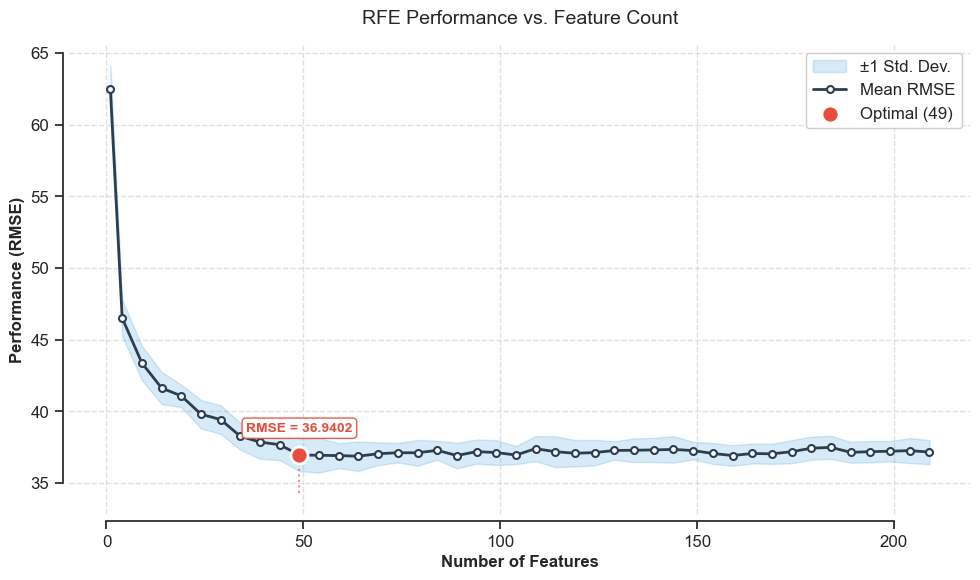

  Optimal Feature Set: 49 features
  Best RMSE: 36.9402


In [80]:
df_lowMW_X_scaled, df_lowMW_X_variance, RFE_results_lowMW_1, df_lowMW_X_final = feature_engineering_workflow('Low MW')

✓ Scaler saved to: ../MW/artifacts_threshold/scaler_high_MW.pkl
✓ Standardization complete. Shape: (1033, 217)
Original features: 217
Removed features: 12
Remaining features: 205


RFE Feature Selection:   2%|▏         | 1/41 iteration

Iteration 0/41 | Features: 200 | RMSE: 48.3194 ± 4.1154 | Removed: [RDKit_NumRadicalElectrons, RDKit_fr_C_S, RDKit_fr_alkyl_carbamate, RDKit_fr_phenol_noOrthoHbond, RDKit_fr_urea]


RFE Feature Selection:  27%|██▋       | 11/41 iteration

Iteration 10/41 | Features: 150 | RMSE: 47.6763 ± 3.9602 | Removed: [RDKit_HeavyAtomCount, RDKit_fr_Ar_N, RDKit_fr_Imine, RDKit_fr_oxime, RDKit_fr_thiophene]


...

RFE Feature Selection:  76%|███████▌  | 31/41 iteration

Iteration 30/41 | Features: 50 | RMSE: 46.7553 ± 5.0472 | Removed: [RDKit_EState_VSA1, RDKit_EState_VSA6, RDKit_LabuteASA, RDKit_MinAbsEStateIndex, RDKit_MolMR]


RFE Feature Selection: 100%|██████████| 41/41 iteration

Iteration 40/41 | Features: 1 | RMSE: 62.4352 ± 3.5387 | Removed: [RDKit_NumRotatableBonds, RDKit_fr_NH1, RDKit_fr_allylic_oxid, RDKit_fr_bicyclic]



Global best RMSE: 46.7553
Threshold (1.0% tolerance): 47.2229

✓ RFE Feature Selection Complete (Parsimonious)
  Selected number of features: 50
  Selected RMSE: 46.7553
  Best features (Top 5): ['RDKit_RingCount', 'RDKit_FractionCSP3', 'RDKit_NumRotatableBonds', 'RDKit_NHOHCount', 'RDKit_fr_bicyclic']


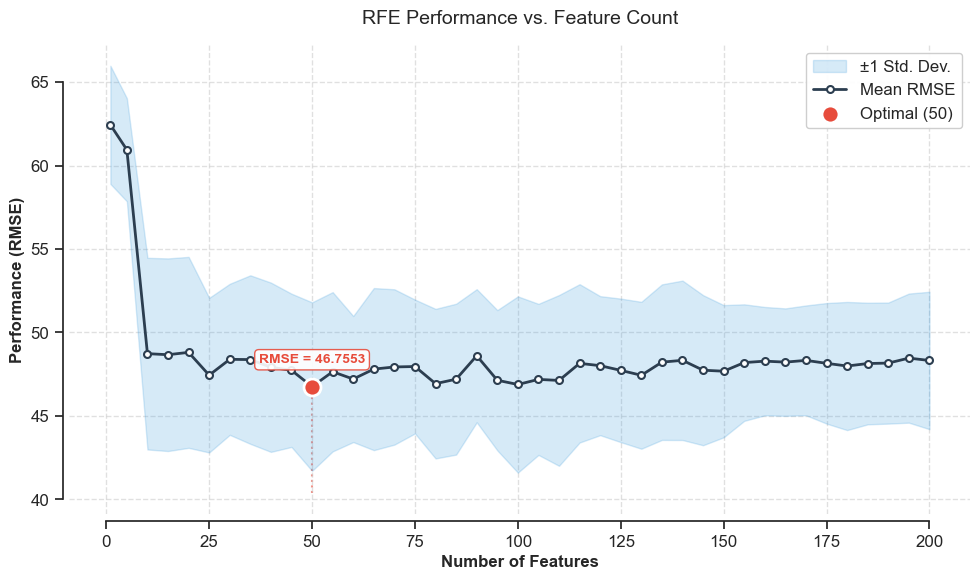

  Optimal Feature Set: 50 features
  Best RMSE: 46.7553


In [81]:
df_highMW_X_scaled, df_highMW_X_variance, RFE_results_highMW_1, df_highMW_X_final = feature_engineering_workflow('High MW')

In [82]:
selected_features = hf.combine_features(df_lowMW_X_final, df_highMW_X_final)

with open(data_prefix_MW + 'selected_feature_list_RDKit_60(split)_MW(label)_90(threshold).pkl', 'wb') as f:
    pickle.dump(selected_features, f)

with open(data_prefix_MW + 'selected_feature_list_RDKit_60(split)_MW(label)_90(threshold).pkl', 'rb') as f:
    selected_features = pickle.load(f)

print(selected_features)
print(len(selected_features))

Number of features in Low MW dataset: 49
Number of features in High MW dataset: 50
Number of overlapping features: 21
Total number of combined features: 78
['RDKit_fr_NH1', 'RDKit_PEOE_VSA3', 'RDKit_VSA_EState9', 'RDKit_SlogP_VSA4', 'RDKit_fr_furan', 'RDKit_PEOE_VSA10', 'RDKit_fr_unbrch_alkane', 'RDKit_PEOE_VSA8', 'RDKit_fr_NH0', 'RDKit_NumAliphaticRings', 'RDKit_Kappa3', 'RDKit_BCUT2D_MWLOW', 'RDKit_FractionCSP3', 'RDKit_NumRotatableBonds', 'RDKit_fr_ether', 'RDKit_MaxPartialCharge', 'RDKit_EState_VSA9', 'RDKit_SMR_VSA4', 'RDKit_PEOE_VSA7', 'RDKit_BCUT2D_CHGHI', 'RDKit_fr_COO', 'RDKit_NHOHCount', 'RDKit_NumHeterocycles', 'RDKit_VSA_EState5', 'RDKit_SMR_VSA3', 'RDKit_NumHeteroatoms', 'RDKit_VSA_EState3', 'RDKit_PEOE_VSA1', 'RDKit_PEOE_VSA2', 'RDKit_fr_para_hydroxylation', 'RDKit_PEOE_VSA12', 'RDKit_SlogP_VSA2', 'RDKit_MolLogP', 'RDKit_MinAbsPartialCharge', 'RDKit_NumBridgeheadAtoms', 'RDKit_fr_Ar_NH', 'RDKit_NumHDonors', 'RDKit_BertzCT', 'RDKit_VSA_EState2', 'RDKit_TPSA', 'RDKit_FpDens

In [83]:
data_with_features = pd.read_parquet(data_prefix_MW + 'all_features_RDKit_60(split)_MW(label)_90(threshold).parquet')
df_final = hf.dataset_featurization(data_with_features, selected_features, data_prefix_MW + 'final_dataset_RDKit_60(split)_MW(label)_90(threshold)')


/Users/sdl5_mp/Documents/GitHub/melting_point_2026/MW/feature_engineering_helper.py:43: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_with_features[f'RDKit_{name}'] = [f[i] for f in rdkit_features]
/Users/sdl5_mp/Documents/GitHub/melting_point_2026/MW/feature_engineering_helper.py:43: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_with_features[f'RDKit_{name}'] = [f[i] for f in rdkit_features]
/Users/sdl5_mp/Documents/GitHub/melting_point_2026/MW/feature_engineering_helper.py:43: PerformanceWarning: DataFrame is highly 

✓ RDKit: Added 217 features
Generating 23436 interaction features from 217 features...
../MW/artifacts_threshold/final_dataset_RDKit_60(split)_MW(label)_90(threshold) dataset saved.


In [84]:
df_final = pd.read_parquet(data_prefix_MW + 'final_dataset_RDKit_60(split)_MW(label)_90(threshold).parquet')

df_final_scaled = hf.standardize_data(df_final, data_prefix_MW + 'df_final_scaler_RDKit_60(split)_MW(label)_90(threshold).pkl')


Number of feature columns to standardize: 78
Scaler saved to ../MW/artifacts_threshold/df_final_scaler_RDKit_60(split)_MW(label)_90(threshold).pkl


In [85]:
import joblib
from pathlib import Path

data_path = Path(data_prefix_MW + "final_dataset_RDKit_60(split)_MW(label)_90(threshold).parquet")
scaler_path = Path(data_prefix_MW + "df_final_scaler_RDKit_60(split)_MW(label)_90(threshold).pkl") 
output_path = Path(data_prefix_MW + "scaled_final_dataset_RDKit_60(split)_MW(label)_90(threshold).parquet")

output_path.parent.mkdir(parents=True, exist_ok=True)

df_final = pd.read_parquet(data_path)


non_feature_cols = ["SMILES", "MP", "Type", "MW_label", "MW"] 
feature_cols = [c for c in df_final.columns if c not in non_feature_cols]



scaler = joblib.load(scaler_path)   # Load saved scaler


# Transform features (NO FITTING)

X_scaled = scaler.transform(df_final[feature_cols]) # Transform features (NO FITTING)

# Replace feature columns with scaled values
df_final_scaled = df_final.copy()
df_final_scaled[feature_cols] = X_scaled

# -------------------------
# Save as parquet
# -------------------------
df_final_scaled.to_parquet(output_path, index=False)

print("Scaled dataset saved to:", output_path)


Scaled dataset saved to: ../MW/artifacts_threshold/scaled_final_dataset_RDKit_60(split)_MW(label)_90(threshold).parquet


In [86]:
df = pd.read_parquet(data_prefix_MW + "scaled_final_dataset_RDKit_60(split)_MW(label)_90(threshold).parquet")
df.head()

,SMILES,MP,Type,MW_label,RDKit_fr_NH1,RDKit_PEOE_VSA3,RDKit_VSA_EState9,RDKit_SlogP_VSA4,RDKit_fr_furan,RDKit_PEOE_VSA10,RDKit_fr_unbrch_alkane,RDKit_PEOE_VSA8,RDKit_fr_NH0,RDKit_NumAliphaticRings,RDKit_Kappa3,RDKit_BCUT2D_MWLOW,RDKit_FractionCSP3,RDKit_NumRotatableBonds,RDKit_fr_ether,RDKit_MaxPartialCharge,RDKit_EState_VSA9,RDKit_SMR_VSA4,RDKit_PEOE_VSA7,RDKit_BCUT2D_CHGHI,RDKit_fr_COO,RDKit_NHOHCount,RDKit_NumHeterocycles,RDKit_VSA_EState5,RDKit_SMR_VSA3,RDKit_NumHeteroatoms,RDKit_VSA_EState3,RDKit_PEOE_VSA1,RDKit_PEOE_VSA2,RDKit_fr_para_hydroxylation,RDKit_PEOE_VSA12,RDKit_SlogP_VSA2,RDKit_MolLogP,RDKit_MinAbsPartialCharge,RDKit_NumBridgeheadAtoms,RDKit_fr_Ar_NH,RDKit_NumHDonors,RDKit_BertzCT,RDKit_VSA_EState2,RDKit_TPSA,RDKit_FpDensityMorgan3,RDKit_HallKierAlpha,RDKit_SlogP_VSA5,RDKit_fr_imidazole,RDKit_EState_VSA10,RDKit_fr_Ar_COO,RDKit_VSA_EState8,RDKit_Phi,RDKit_MinPartialCharge,RDKit_NOCount,RDKit_SlogP_VSA1,RDKit_fr_allylic_oxid,RDKit_SlogP_VSA8,RDKit_PEOE_VSA6,RDKit_fr_SH,RDKit_qed,RDKit_VSA_EState6,RDKit_Kappa2,RDKit_VSA_EState10,RDKit_fr_ArN,RDKit_fr_Al_OH,RDKit_MinEStateIndex,RDKit_VSA_EState4,RDKit_fr_Ar_OH,RDKit_Chi0,RDKit_fr_nitrile,RDKit_SMR_VSA7,RDKit_SMR_VSA10,RDKit_RingCount,RDKit_FpDensityMorgan2,RDKit_fr_ester,RDKit_fr_ketone,RDKit_VSA_EState1,RDKit_SMR_VSA6,RDKit_fr_bicyclic,RDKit_SMR_VSA5,RDKit_PEOE_VSA11,RDKit_BCUT2D_CHGLO
0,CCN(c1ccc(cc1)C(=O)CBr)CC,51.0,Train,0,-0.464936,-0.655578,-0.155517,-0.655946,-0.134995,-0.726634,-0.171379,1.456094,0.200590,-0.501594,-0.022257,0.003941,0.398763,0.648859,-0.526623,-0.537522,-0.814958,-0.421442,0.613323,-0.572780,-0.366566,-0.842757,-0.670348,0.096152,-0.575081,-0.503669,-0.816213,-0.348659,-0.000385,-0.354471,-0.426292,0.346934,0.246094,-0.528968,-0.154203,-0.196622,-0.861148,-0.548272,0.161015,-0.899915,-0.181490,0.696467,0.152741,-0.132473,-0.379139,-0.215661,1.306249,0.343882,0.133917,-0.607841,0.191559,-0.205871,-0.472032,-0.324043,-0.071305,0.099621,0.061151,0.252440,0.196408,-0.269288,-0.281448,0.572259,0.054872,-0.300675,-0.214495,-0.228343,-0.284821,0.679837,-0.671982,0.017158,-0.331997,1.772180,-0.447308,1.855583,-0.464369,-0.190140,0.547866,-0.539673
1,CN(c1ccc(cc1)/C=C/c1nc2c(s1)cccc2)C,210.0,Train,0,-0.464936,0.415140,2.523810,-0.655946,-0.134995,-0.023411,-0.171379,0.991373,1.075429,-0.501594,-0.024476,0.036413,-0.610669,0.045899,-0.526623,-1.006044,-0.814958,-0.421442,0.502250,-0.837016,-0.366566,-0.842757,0.586418,0.066463,0.427145,-0.503669,-0.746787,-0.348659,-0.785801,1.693846,-0.426292,0.042896,0.964858,-1.042045,-0.154203,-0.196622,-0.861148,0.750633,-0.432212,-1.021387,0.328898,-0.566571,-0.391898,-0.132473,-0.922026,-0.215661,-0.655375,-0.087885,0.085465,-0.607841,0.191559,-0.205871,2.797433,0.238085,-0.071305,0.679307,1.275772,0.117634,-0.103228,-0.269288,-0.281448,1.215096,0.586207,-0.300675,0.296906,-0.228343,0.832660,1.493806,0.858643,-0.060077,-0.331997,-0.347788,-0.382383,1.387123,0.333944,-0.685447,-0.538868,-0.035521
2,CO/C=C(\[C@H]1C[C@@H]2N(C[C@@H]1CC)CC[C@@]12C(...,216.0,Train,0,1.281237,0.374442,1.777668,0.564624,-0.134995,-0.726634,-0.171379,0.837533,0.200590,2.319564,-0.024964,-0.379672,0.833526,0.347379,1.577020,0.832255,0.088744,1.088220,0.851721,1.956534,-0.366566,-0.062317,3.099948,0.084592,0.410239,0.586764,-0.530362,0.986114,0.802292,1.693846,1.171140,1.885337,0.038798,0.971069,-0.154203,-0.196622,0.060097,1.132758,1.400379,0.482189,1.203849,-0.770601,0.454101,-0.132473,0.163749,-0.215661,0.582911,0.374520,-1.011859,1.062873,0.272776,-0.205871,-0.472032,0.284976,-0.071305,-0.592196,0.101294,0.662803,-0.458850,-0.269288,-0.281448,0.106161,0.093119,-0.300675,1.425912,-0.228343,0.166979,0.012175,1.623955,0.966044,1.510211,-0.347788,0.093543,2.863770,2.728883,0.660997,-0.538868,-1.852528
3,CCCCc1c(C)nc(nc1O)NCC,160.0,Train,0,1.281237,0.415140,-0.155517,0.058066,-0.134995,-0.726634,0.270079,0.789421,1.075429,-0.501594,-0.022149,-0.021647,1.140417,0.648859,-0.526623,-0.095592,-0.814958,-0.421442,0.038652,-0.381891,-0.366566,